# Seismic signals preprocessing and exploration

This notebook covers the loading, preprocessing, and exploratory analysis of the seismic acceleration signals.

Two separate preprocessing pipelines are applied:

1. **Pipeline A (PDF analysis)**: Applied to all 66 signals with baseline correction and normalization. The normalized data is used for PDF analysis, heavy-tail assessment, and cross-station comparisons of distribution shapes.

2. **Pipeline B (Moment scaling analysis)**: Applied to 48 signals (excluding the 6 short-signal stations: SURF, BRZ, BHB, CRI, SLZ, SAV) with baseline correction but **without normalization**. This preserves physical units (cm/s²), which is essential for integration to compute velocity and displacement in the moment scaling analysis.

**Key difference**: Pipeline A creates both `acceleration` and `acceleration_normalized` columns, while Pipeline B creates only `acceleration` (preserving physical units for integration).

## 1. Imports and visualization settings

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import logging
from src import (
    build_accelerations,
    build_metadata,
    preprocess_signals,
    validate_preprocessing,
    clean_metadata,
    set_plot_style,
    preprocess_checks_to_latex,
    plot_signal_length_distribution,
    plot_three_components,
    plot_acceleration_distributions,
    plot_postcheck_pdf,
    plot_postcheck_moment_scaling)
from IPython.display import display
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Raw acceleration data are loaded from the zip archive containing the `.ASC` files.
The function `build_accelerations` extracts the acceleration time series from 
each file and returns a dataframe with columns `file`, `sample`, and `acceleration`.

In [8]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Define all paths from project root
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '02_signals'
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(DATA_PROCESSED.exists(), f"Processed data directory ready: {DATA_PROCESSED}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/02_signals
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed data directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed


In [9]:
# Load data
logger.info("Loading accelerations...")
df_acc = build_accelerations(DATA_RAW   / 'query.zip')
df_meta = pd.read_parquet(DATA_PROCESSED / '01_metadata' / 'metadata_clean.parquet')

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}\n")

# Check if accelerations were loaded successfully
check(df_acc is not None, "Accelerations dataframe created")
check(len(df_acc) > 0, "Accelerations dataframe is not empty")
logger.info(f"Accelerations dataframe loaded, shape: {df_acc.shape}\n")

INFO | Loading accelerations...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (66, 38)

INFO | Accelerations dataframe created
INFO | Accelerations dataframe is not empty
INFO | Accelerations dataframe loaded, shape: (2614815, 3)



In [10]:
FIGURES_DIR = Path('../figures/02_signals')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")

INFO | Figures directory ready: ../figures/02_signals


## 3. Signals exploration

A first exploration of the raw acceleration signals is performed to understand 
the structure of the dataset before preprocessing. Signal lengths, amplitude 
distributions, and example waveforms are inspected.

### Signal length distribution

The number of samples varies across signals. Understanding the distribution 
of signal lengths is important for deciding how to handle signals of different 
lengths in the aggregated analysis.

INFO | Plotting signal length distribution...
INFO | N files: 66 — lengths range: 6000–56000 samples


Saved: ../figures/02_signals/signal_length_distribution.pdf


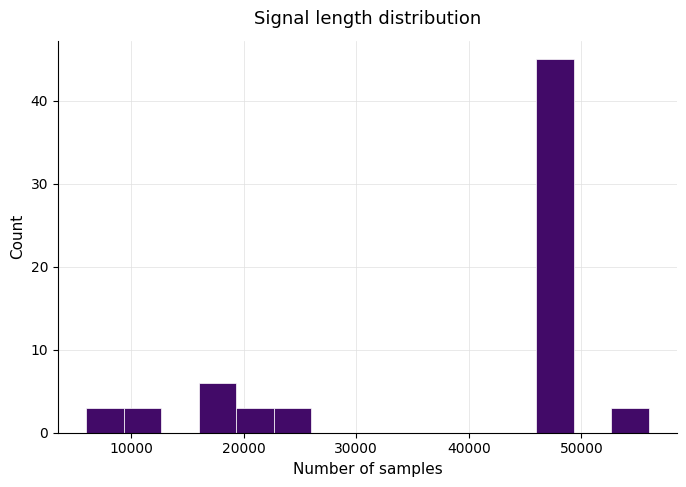

In [4]:
logger.info("Plotting signal length distribution...")
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
logger.info(f"N files: {len(signal_lengths)} — lengths range: "
            f"{signal_lengths.min()}–{signal_lengths.max()} samples")
plot_signal_length_distribution(signal_lengths, output_dir=FIGURES_DIR)

### Acceleration distribution

The distribution of acceleration values is visualized on a logarithmic scale 
to better appreciate the heavy tails of the distribution. The dominance of 
near-zero values reflects the long pre-event and post-event noise windows.

Saved: ../figures/02_signals/acceleration_distribution.pdf


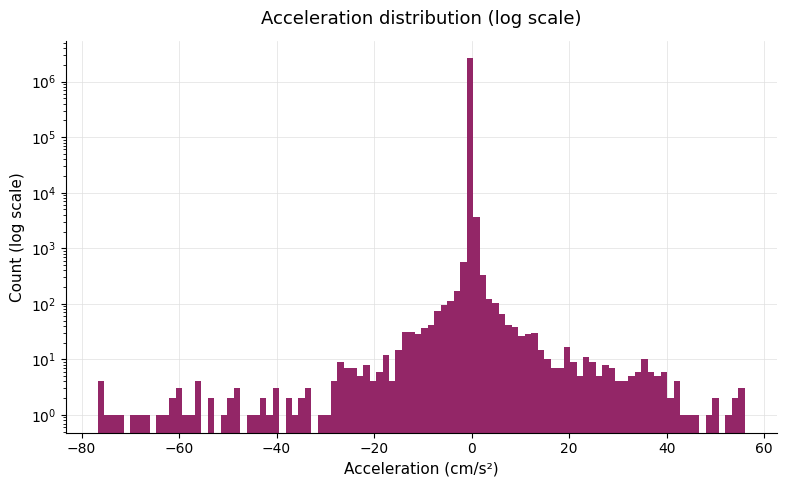

Saved: ../figures/02_signals/acceleration_by_component.pdf


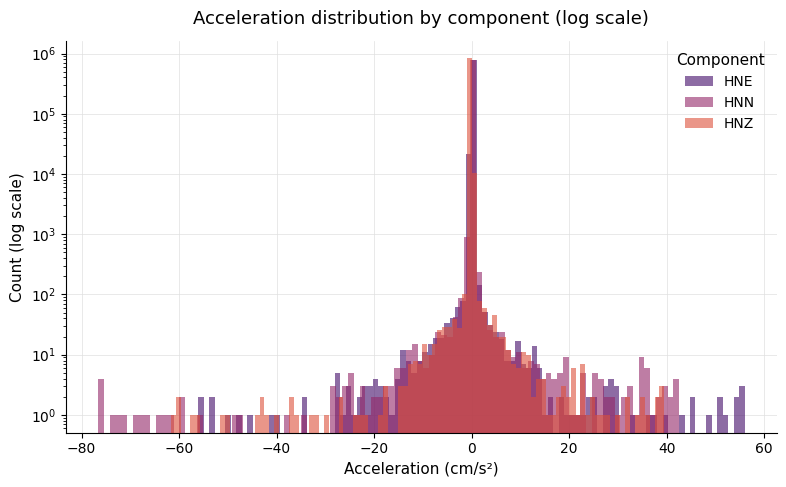

In [ ]:
plot_acceleration_distributions(df_acc, df_meta, output_dir=FIGURES_DIR)

### Extreme acceleration values check

Signals with acceleration values below $-40$ cm/s² are identified to verify 
that extreme values are physically plausible and not due to data errors.

In [7]:
print(df_acc[df_acc['acceleration'] < -40]['file'].unique())

['FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC']


## 4. Preprocessing - PDF analysis pipeline

### Preprocessing

In [8]:
logger.info("Preprocessing signals — PDF analysis pipeline")
df_acc_pdf = preprocess_signals(
    df_acc,
    filter_length=False,        # Use all 66 files
    baseline_correction=True,   # Remove baseline
    normalize=True              # Normalize for PDF comparison
)

INFO | Preprocessing signals — PDF analysis pipeline


Length filtering: DISABLED (using all 66 files)
Baseline correction: max residual mean = 1.91e-17 cm/s²
Normalization: mean std = 1.0000000000 (expected: 1.0)


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that baseline correction 
and normalization have been applied correctly. The preprocessed data are 
saved to a parquet file for use in notebook 03.

In [9]:
validate_preprocessing(df_acc_pdf, expected_files=66, 
                      check_normalized=True, pipeline_name="PDF analysis")

display(df_acc_pdf.head())
display(df_acc_pdf[['acceleration', 'acceleration_normalized']].describe())

INFO | Running quality checks — PDF analysis pipeline
INFO | Baseline corrected: max residual = 1.91e-17 cm/s²
INFO | Normalized: mean std = 1.0000000000
INFO | No NaN in acceleration
INFO | No NaN in acceleration_normalized
INFO | No Inf in acceleration
INFO | No Inf in acceleration_normalized
INFO | All 66 files retained
INFO | All checks passed. Shape: (2614815, 4)


,file,sample,acceleration,acceleration_normalized
0,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,0,-6.666667e-10,-3.401661e-08
1,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,1,-6.666667e-10,-3.401661e-08
2,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,2,-6.666667e-10,-3.401661e-08
3,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,3,-6.666667e-10,-3.401661e-08
4,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,4,-6.666667e-10,-3.401661e-08


,acceleration,acceleration_normalized
count,2.614815e+06,2.614815e+06
mean,4.731320e-20,6.854573e-19
std,3.865810e-01,9.999876e-01
min,-7.663142e+01,-3.300176e+01
25%,-9.249986e-04,-5.137990e-02
50%,-5.000000e-10,-2.139984e-08
75%,9.219988e-04,5.086609e-02
max,5.600939e+01,3.318042e+01


Saved: ../figures/02_signals/postcheck_single.pdf


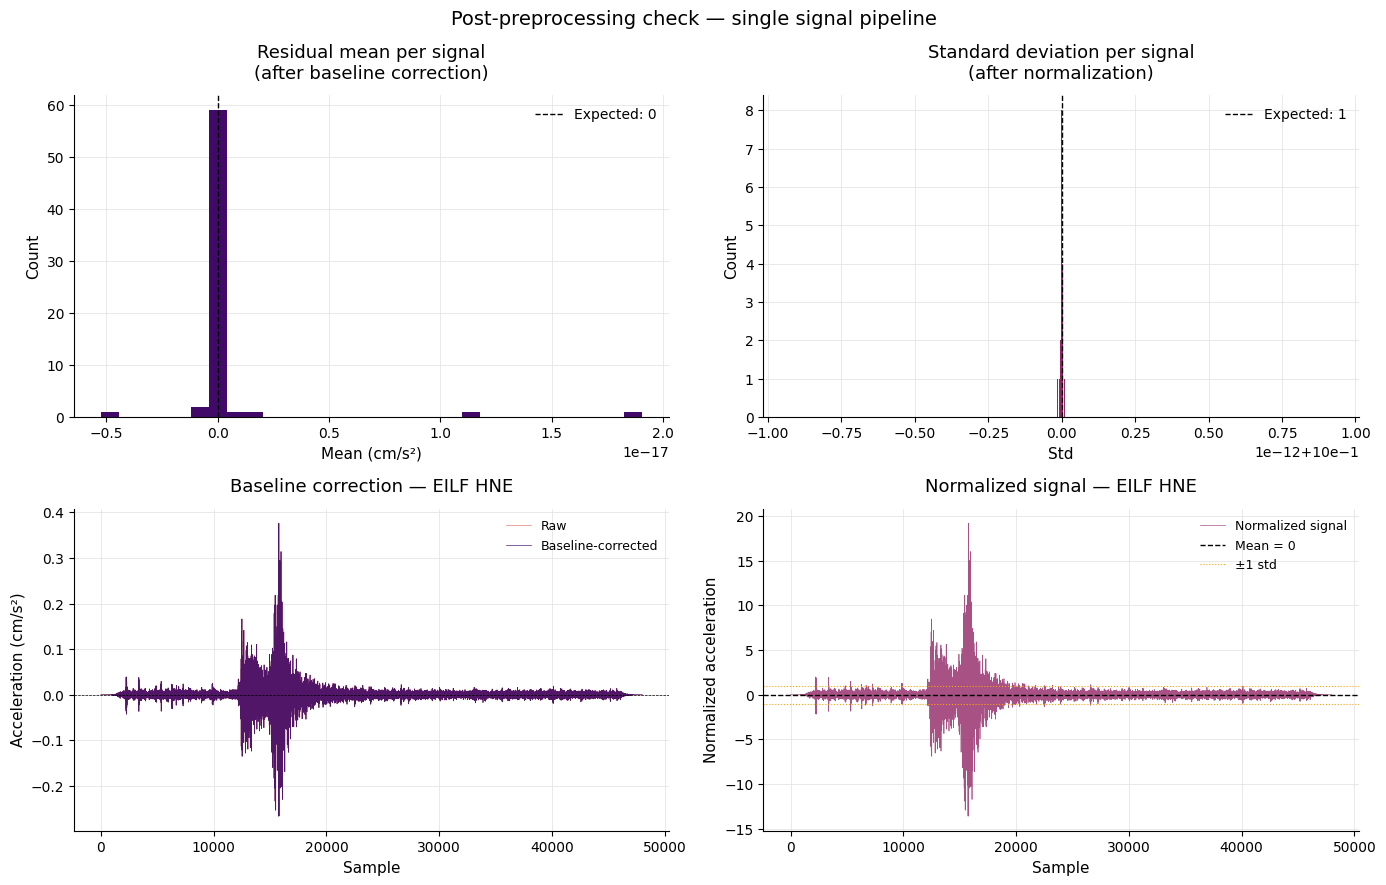

In [10]:
plot_postcheck_pdf(df_acc, df_acc_pdf, output_dir=FIGURES_DIR)

In [11]:
logger.info("Saving preprocessed data")
try:
    df_acc_pdf.to_parquet('../data/processed/02_signals/acc_preprocessed_pdf.parquet', index=False)
    logger.info("Saved: acc_preprocessed_pdf.parquet")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: acc_preprocessed_pdf.parquet


In [ ]:
plot_three_components(df_acc_pdf, df_meta, output_dir=FIGURES_DIR / 'accelerograms')

## 5. Filtered preprocessing for moment scaling analysis

The moment scaling analysis (notebooks 3 and 4) requires signals of sufficient length to produce reliable displacement increment estimates at large time scales $\tau$. Signals with fewer than 48,000 samples (stations SURF, BRZ, BHB, CRI, SLZ, SAV) are excluded. The remaining 48 signals are saved separately. The preprocessing pipeline consists of three steps:

1. **Truncation** — only signals with at least $48000$ samples are retained, 
   and all signals are truncated to exactly $48000$ samples. This excludes 
   6 stations (SURF, BRZ, BHB, CRI, SLZ, SAV) whose signals are shorter 
   due to their proximity to the epicenter.

2. **Baseline correction** — same as in the single signal pipeline.

3. **Normalization** — same as in the single signal pipeline.

In [11]:
# Display signal length distribution
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
pd.set_option('display.max_rows', None)
print(signal_lengths.sort_values())
pd.reset_option('display.max_rows')

file
FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC     6000
IT.BRZ..HGE.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGZ.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGN.D.INT-41004391.ACC.MP.ASC       11001
GU.BHB..HNE.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNN.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNZ.D.INT-41004391.ACC.MP.ASC       16601
IT.CRI..HNZ.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNE.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNN.D.INT-41004391.ACC.MP.ASC       19001
IT.SLZ..HNZ.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNN.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNE.D.INT-41004391.ACC.MP.ASC       20001
IT.SAV..HGE.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGN.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGZ.D.INT-41004391.ACC.MP.ASC       23001
FR.SAOF.00.HNN.D.INT-41004391.ACC.MP.ASC    48000
FR.REVF.00.HN2.D.INT-41004391.ACC.MP.ASC    4

### Preprocessing

In [12]:
logger.info("Preprocessing signals — Moment scaling pipeline")
df_acc_scaling = preprocess_signals(
    df_acc,
    filter_length=False,
    baseline_correction=True,
    normalize=False
)

INFO | Preprocessing signals — Moment scaling pipeline


Length filtering: DISABLED (using all 66 files)
Baseline correction: max residual mean = 1.91e-17 cm/s²
Normalization: DISABLED (physical units preserved)


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that filtering, baseline correction, and normalization have been applied correctly. The preprocessed data are saved to a parquet file for use in notebooks 3 and 4.

In [15]:
validate_preprocessing(df_acc_scaling, expected_files=66,
                      check_normalized=False, pipeline_name="Moment scaling")

display(df_acc_scaling.head())
display(df_acc_scaling[['acceleration']].describe())

INFO | Running quality checks — Moment scaling pipeline
INFO | Baseline corrected: max residual = 1.91e-17 cm/s²
INFO | Not normalized (physical units preserved)
INFO | No NaN in acceleration
INFO | No Inf in acceleration
INFO | All 66 files retained
INFO | All checks passed. Shape: (2614815, 3)


,file,sample,acceleration
0,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,0,-6.666667e-10
1,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,1,-6.666667e-10
2,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,2,-6.666667e-10
3,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,3,-6.666667e-10
4,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,4,-6.666667e-10


,acceleration
count,2.614815e+06
mean,4.731320e-20
std,3.865810e-01
min,-7.663142e+01
25%,-9.249986e-04
50%,-5.000000e-10
75%,9.219988e-04
max,5.600939e+01


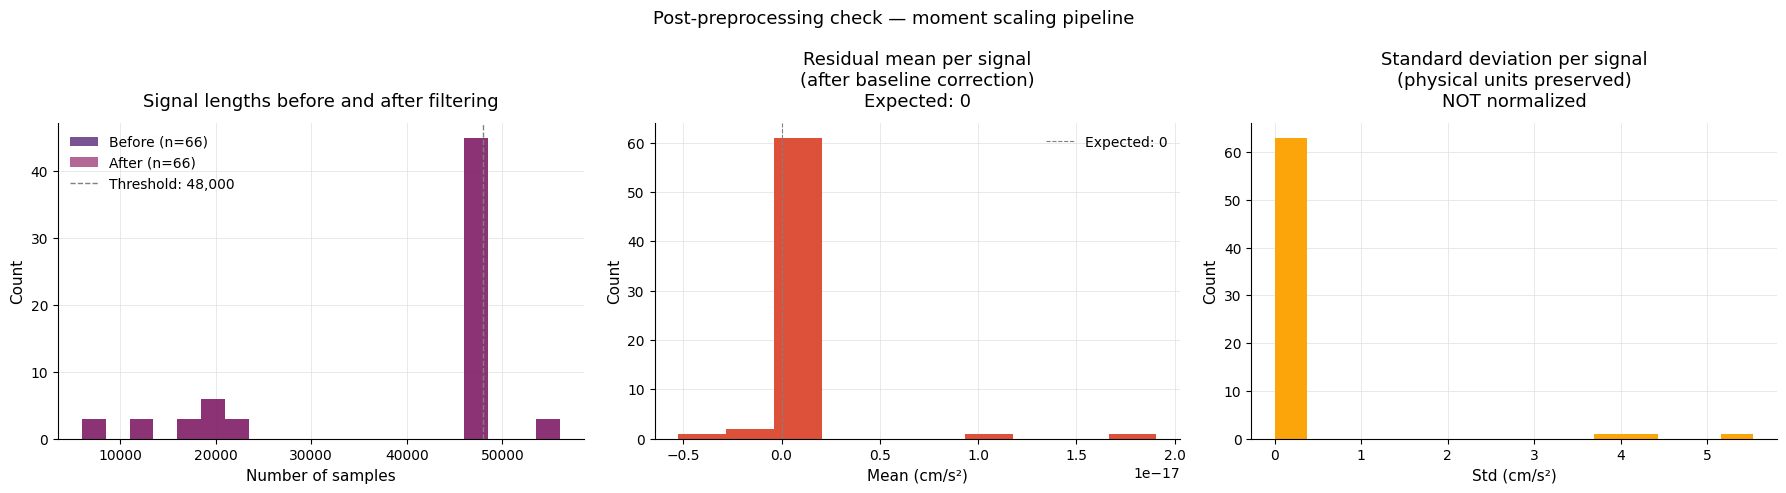

In [16]:
plot_postcheck_moment_scaling(df_acc, df_acc_scaling, output_dir=FIGURES_DIR)

In [17]:
logger.info("Saving preprocessed data")
try:
    df_acc_scaling.to_parquet('../data/processed/02_signals/acc_preprocessed_scaling.parquet', index=False)
    logger.info("Saved: acc_preprocessed_scaling.parquet")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: acc_preprocessed_scaling.parquet


## Summary

In [18]:
# Variabili per la summary table
signal_lengths_raw = df_acc.groupby('file')['sample'].max() + 1

# Pipeline A (PDF) - con normalizzazione
baseline_check_pdf = df_acc_pdf.groupby('file')['acceleration'].mean()
norm_check_pdf = df_acc_pdf.groupby('file')['acceleration_normalized'].std()

bl_max_pdf = baseline_check_pdf.abs().max()
bl_pass_pdf = bl_max_pdf < 1e-10
std_mean_pdf = norm_check_pdf.mean()
std_pass_pdf = ((norm_check_pdf - 1).abs() > 1e-6).sum() == 0
nan_acc_pdf = df_acc_pdf['acceleration'].isna().sum()
nan_norm_pdf = df_acc_pdf['acceleration_normalized'].isna().sum()
inf_acc_pdf = np.isinf(df_acc_pdf['acceleration']).sum()
inf_norm_pdf = np.isinf(df_acc_pdf['acceleration_normalized']).sum()
n_files_pdf = df_acc_pdf['file'].nunique()

# Pipeline B (Moment scaling) - SENZA normalizzazione
baseline_check_scaling = df_acc_scaling.groupby('file')['acceleration'].mean()

bl_max_scaling = baseline_check_scaling.abs().max()
bl_pass_scaling = bl_max_scaling < 1e-10
nan_acc_scaling = df_acc_scaling['acceleration'].isna().sum()
inf_acc_scaling = np.isinf(df_acc_scaling['acceleration']).sum()
n_files_scaling = df_acc_scaling['file'].nunique()
n_excluded = len(signal_lengths_raw) - n_files_scaling

# Summary table
rows = [
    ('Files retained',
     f'{n_files_pdf} / {len(signal_lengths_raw)}',
     f'{n_files_scaling} / {len(signal_lengths_raw)} ({n_excluded} excluded)',
     '—', '—'),
    
    ('Max residual mean (cm/s²)',
     f'{bl_max_pdf:.2e}',
     f'{bl_max_scaling:.2e}',
     '< 1e-10',
     '\\checkmark' if (bl_pass_pdf and bl_pass_scaling) else '\\times'),
    
    ('Mean std (normalized)',
     f'{std_mean_pdf:.8f}',
     'N/A (not normalized)',  # ← NON normalizzato!
     '$\\approx 1$',
     '\\checkmark' if std_pass_pdf else '\\times'),
    
    ('NaN in acceleration',
     str(nan_acc_pdf),
     str(nan_acc_scaling),
     '0',
     '\\checkmark' if nan_acc_pdf == 0 and nan_acc_scaling == 0 else '\\times'),
    
    ('NaN in acceleration\\_normalized',
     str(nan_norm_pdf),
     'N/A (column not present)',  # ← Colonna non esiste!
     '0',
     '\\checkmark' if nan_norm_pdf == 0 else '\\times'),
    
    ('Inf in acceleration',
     str(inf_acc_pdf),
     str(inf_acc_scaling),
     '0',
     '\\checkmark' if inf_acc_pdf == 0 and inf_acc_scaling == 0 else '\\times'),
    
    ('Inf in acceleration\\_normalized',
     str(inf_norm_pdf),
     'N/A (column not present)',  # ← Colonna non esiste!
     '0',
     '\\checkmark' if inf_norm_pdf == 0 else '\\times'),
]

df_check = pd.DataFrame(rows, columns=['Check', 'PDF Analysis', 'Moment Scaling', 'Expected', 'Pass'])
display(df_check)

,Check,PDF Analysis,Moment Scaling,Expected,Pass
0,Files retained,66 / 66,66 / 66 (0 excluded),—,—
1,Max residual mean (cm/s²),1.91e-17,1.91e-17,< 1e-10,\checkmark
2,Mean std (normalized),1.00000000,N/A (not normalized),$\approx 1$,\checkmark
3,NaN in acceleration,0,0,0,\checkmark
4,NaN in acceleration\_normalized,0,N/A (column not present),0,\checkmark
5,Inf in acceleration,0,0,0,\checkmark
6,Inf in acceleration\_normalized,0,N/A (column not present),0,\checkmark


In [19]:
latex_table = preprocess_checks_to_latex(
    rows, output_path='../data/processed/latex_tables/preprocess_checks_table.tex')
logger.info("LaTeX table saved: preprocess_checks_table.tex")

INFO | LaTeX table saved: preprocess_checks_table.tex


Saved to: ../data/processed/latex_tables/preprocess_checks_table.tex
